<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Margin and Hyperplane Intuition</b>
</h1>

<div style="font-family:'Times New Roman';">

<b>Goal:</b>

<ol>
<li>Understand what a hyperplane is.</li>
<li>Understand the concept of margin.</li>
<li>Learn what support vectors are.</li>
<li>Build intuition for how SVM works.</li>
</ol>

In this notebook, I'll understand how SVM separates classes and why maximizing the margin helps create better decision boundaries.

</div>

In [30]:
# Importing the libraries we need

import numpy as np
import matplotlib.pyplot as plt

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Creating Synthetic Data</b>
</h2>
<div style="font-family:'Times New Roman';">
Before understanding SVM, I need some data to work with. Instead of using a real dataset, 
I'll create my own <b>synthetic data</b> — basically two groups (classes) of points that 
are clearly separable. This will help me visualize the hyperplane and margin without 
any extra complexity.
</div>

In [ ]:
np.random.seed(42)

class_0 = np.random.randn(20, 2) + np.array([2, 2])

class_1 = np.random.randn(20, 2) + np.array([6, 6])

X = np.vstack((class_0, class_1))
y = np.array([0]*20 + [1]*20)  # labels: 0 for class_0, 1 for class_1

print("Shape of data:", X.shape)
print("Shape of labels:", y.shape)

Shape of data: (40, 2)
Shape of labels: (40,)


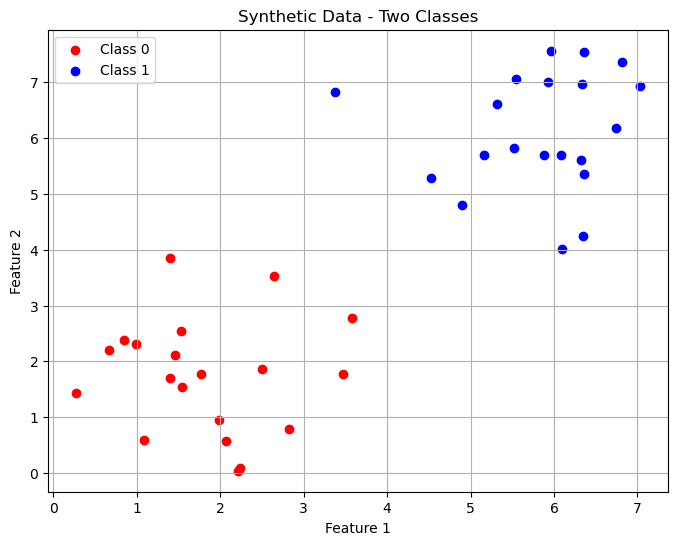

In [32]:
# Visualize the data 
plt.figure(figsize=(8, 6))

plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Class 0')

plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class 1')

plt.title("Synthetic Data - Two Classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What is a Hyperplane?</b>
</h2>
<div style="font-family:'Times New Roman';">
A <b>hyperplane</b> is simply the boundary that separates the two classes. 
In 2D, this boundary is just a straight line. In higher dimensions, 
it becomes a plane (3D) or a more general "hyperplane" (n-dimensions).
<br><br>
Mathematically, a hyperplane is represented as:
<br>
<b>w · x + b = 0</b>
<br><br>
Here, I'll manually pick values for <b>w</b> (the slope/direction) and 
<b>b</b> (the intercept) so I can draw a line that separates my two classes.
</div>

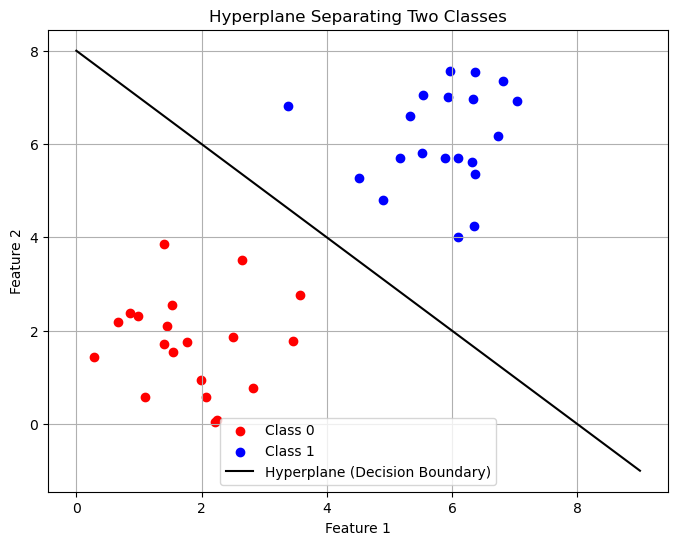

In [33]:
# Manually choosing a hyperplane that separates the two classes
# Equation: w1*x1 + w2*x2 + b = 0 -> rearranged to x2 = -(w1*x1 + b)/w2

w = np.array([1, 1])   # direction of the hyperplane
b = -8                  # intercept (shifts the line)

# Generating x1 values across the plot range
x1 = np.linspace(0, 9, 50)

# Calculating corresponding x2 values for the hyperplane
x2 = -(w[0]*x1 + b) / w[1]

# Plotting data again along with the hyperplane
plt.figure(figsize=(8, 6))
plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class 1')

# The hyperplane (decision boundary)
plt.plot(x1, x2, color='black', label='Hyperplane (Decision Boundary)')

plt.title("Hyperplane Separating Two Classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What is Margin?</b>
</h2>
<div style="font-family:'Times New Roman';">
The <b>margin</b> is the empty space between the hyperplane and the closest 
data points from each class. 
<br><br>
SVM doesn't just find <i>any</i> separating line it finds the one that 
keeps the <b>maximum possible distance</b> from both classes. This gap 
is called the margin, and it's bounded by two parallel lines on either 
side of the hyperplane.
<br><br>
A larger margin generally means the model will generalize better to new, 
unseen data.
</div>

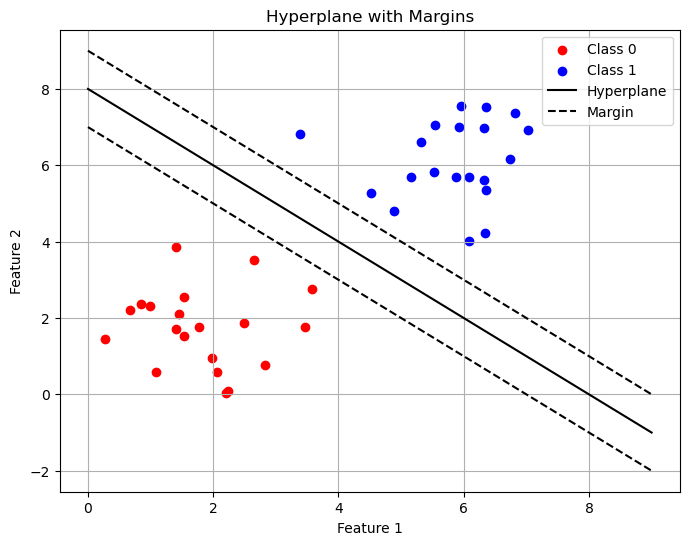

In [ ]:
# To draw the margin lines, I shift the hyperplane up and down by a fixed amount
# These represent: w·x + b = 1 and w·x + b = -1

margin = 1.0  # how far the margin lines are from the hyperplane

x2_upper = -(w[0]*x1 + (b - margin)) / w[1]  # margin line above
x2_lower = -(w[0]*x1 + (b + margin)) / w[1]  # margin line below

plt.figure(figsize=(8, 6))
plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class 1')

# Hyperplane
plt.plot(x1, x2, color='black', label='Hyperplane')

# Margin lines 
plt.plot(x1, x2_upper, 'k--', label='Margin')
plt.plot(x1, x2_lower, 'k--')

plt.title("Hyperplane with Margins")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>What are Support Vectors?</b>
</h2>
<div style="font-family:'Times New Roman';">
<b>Support vectors</b> are the data points that lie closest to the 
hyperplane, basically, they "touch" or sit right on the margin lines.
<br><br>
These points are the most important ones in the entire dataset because 
they are the ones that actually decide where the hyperplane and margin 
will be.

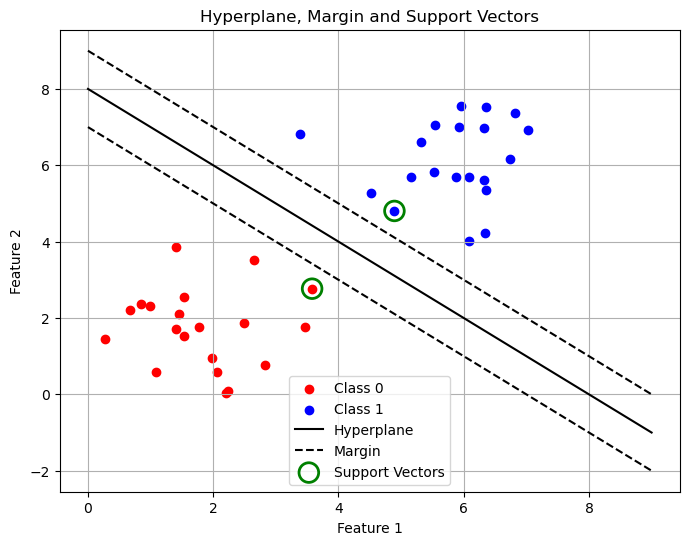

In [ ]:
# Since we're not training a model, I'll manually pick the points
# that are closest to the hyperplane to act as our "support vectors"

# Calculating distance of each point from the hyperplane: |w·x + b|
distances = np.abs(X @ w + b)

# Getting the indices of the 2 closest points from each class
class_0_idx = np.argsort(distances[:20])[:1]          # closest from class 0
class_1_idx = np.argsort(distances[20:])[:1] + 20      # closest from class 1

support_vectors = X[np.concatenate([class_0_idx, class_1_idx])]

plt.figure(figsize=(8, 6))
plt.scatter(class_0[:, 0], class_0[:, 1], color='red', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class 1')

# Hyperplane and margins
plt.plot(x1, x2, color='black', label='Hyperplane')
plt.plot(x1, x2_upper, 'k--', label='Margin')
plt.plot(x1, x2_lower, 'k--')

# Highlighting support vectors with green circles
plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
            s=200, facecolors='none', edgecolors='green',
            linewidths=2, label='Support Vectors')

plt.title("Hyperplane, Margin and Support Vectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li><b>Hyperplane:</b> The decision boundary that separates the two classes.</li>
<li><b>Margin:</b> The gap between the hyperplane and the closest points from either class. SVM tries to maximize this.</li>
<li><b>Support Vectors:</b> The data points closest to the hyperplane </li>
</ul>
With this intuition, the next notebook can move on to actually training an 
SVM model and seeing how it automatically finds the best hyperplane and 
margin from the data.
</div>